In [5]:
import numpy as np
import matplotlib.pyplot as plt 

## Desiderata 

Make a dataset of ring images with different radii and decay for the ring. We can keep the resolution low to keep resources low for the training of our compressor/encoder/embedding function. 

I propose to have a resolution around $64 \times 64$ pixels. 
1) The radius can be uniformly sampled as $$r\sim \mathcal{U}(10, 30)$$ (here the units of $r$ is in number of pixels)
2) The decay can be sampled uniformly as well. 

The equation of the ring to implement depends on two independent parameters/causes: 
$$
I(x, y) = \exp\left(-\frac{(\sqrt{x^2 + y^2} - R)^2}{\lambda}\right)
$$

$\lambda$ controls the thickness of the ring here.  

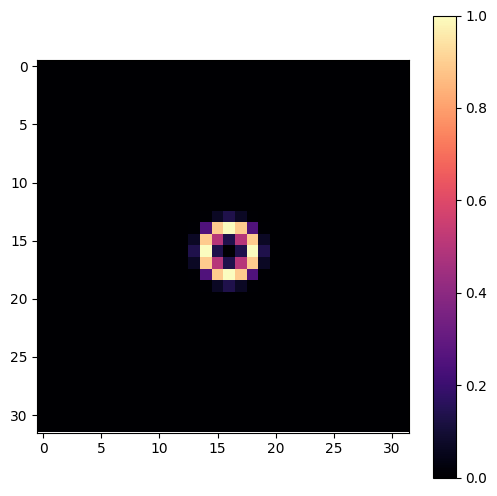

In [29]:
from functools import partial

def make_rings(x, y, radius = 10, sigma = 3, center = 32//2): 
    """
    x and y are arrays created from a np.meshgrid. 
    """
    r =  np.sqrt((x-center) ** 2 + (y - center) ** 2)
    return np.exp( - (r - radius) ** 2 / sigma)

x = np.arange(0, 32)
y = np.arange(0, 32)
X, Y = np.meshgrid(x,y)

ring = make_rings(X, Y, sigma = 5e-1, radius = 2)

fig, axs = plt.subplots(1, 1, figsize = (6, 6))

im = axs.imshow(ring, cmap = "magma", vmin = 0, vmax = 1)
plt.colorbar(im)

Now, sample the ring parameters from uniform prior distributions

In [51]:
from tqdm import tqdm 
prior_params_config = {
    "radius": {"low": 2, "high": 30}, 
    "sigma": {"low": 0.5, "high": 5}
}

radius_prior = prior_params_config["radius"]
sigma_prior = prior_params_config["sigma"]
prior_sampler_radius = lambda size: np.random.uniform(radius_prior["low"], radius_prior["high"], size = size)
prior_sampler_sigma = lambda size: np.random.uniform(sigma_prior["low"], sigma_prior["high"], size = size)

dataset_size = 10_000

# Creating latent factors
radius = prior_sampler_radius(size = dataset_size)
sigma = prior_sampler_sigma(size = dataset_size)
theta = np.stack([radius, sigma]).T

# Creating simulations from it 
images = []
for params in tqdm(theta): 
    image = make_rings(X, Y, radius = params[0], sigma = params[1], center = 32//2)
    images.append(image) 

images = np.array(images)

100%|██████████| 10000/10000 [00:00<00:00, 26750.10it/s]


### Saving the dataset. 

In [57]:
from datasets import Dataset
dset = Dataset.from_dict({
            "theta": theta,
            "image": images 
        })
dset.save_to_disk("C:/Users/Admin/Desktop/Research/Projects/classes/causal_representation/data/rings")

Saving the dataset (1/1 shards): 100%|██████████| 10000/10000 [00:00<00:00, 123440.30 examples/s]


In [52]:
images.shape

(10000, 32, 32)

In [45]:
theta

array([[ 2.51924828,  1.32726946],
       [11.25608679,  2.94860188],
       [25.30580591,  3.55337543],
       ...,
       [16.83613704,  4.68497306],
       [11.77987747,  2.38560095],
       [15.44827074,  4.26264754]], shape=(10000, 2))